# TornadoQ Pipeline
We use xgboost on the given datasets to classifiy tornadoes. We show the results for both the binary (weak and strong) classification and the classification into specific EF categories, called multiclass. We also have ignored the XGBoost portion of the pipeline. Currently we comapre a classical DNN (baseline) with 
* Hybrid DNN - Classical DNN with the dataset enhanced via quantum feature engineering
* QNN - Strongly Entangling Ansatz with original dataset
* QNN - RandomLayers Ansatz with original dataset


# Relevant Imports and Global Variables

In [1]:
import torch
from torch.utils.data import DataLoader
from tornadoq.preprocessing import (
    ClassificationDataset,
    Preprocess,
    DataMaker,
)
from tornadoq.train import train
from tornadoq.models import InitializeModel
from tornadoq.loadSaveEval import eval_and_plot

In [2]:
classifier = 'binary' # binary or multiclass

# These can be in either .xlsx or .csv
TRAIN_FILE = "../Data/NOAA/train.csv"
VAL_FILE   = "../Data/NOAA/val.csv"
TEST_FILE  = "../Data/NOAA/test.csv"

# pytorch device 
# device = 'nps' if torch.mps.is_available() else 'cpu' # For Andrei's mac.
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# fontsize for graphs and plots
fontsize = 12


## Binary Classification with XGBoost

In [3]:
# # -------------------------
# # Config
# # -------------------------
# models_to_test = ["xgb"] # choose from any number of "logreg", "rf" "gb" and "xgb". Note RAM issues may surface.


# TRAIN_FILE = "../Data/original/2025-Quantathon-Tornado-Q-training_data-640-examples.xlsx"
# VAL_FILE   = "../Data/original/2025-Quantum-Tornado-validation_data-160-examples.xlsx"
# TEST_FILE  = "../Data/original/2025-Quantum-Tornado-Q-test_data-200-examples.xlsx"

# cv_cfg = CVConfig(folds=5, shuffle=True, random_state=42, repeats=1)
# cv_metric = "cv_roc_auc_mean"   # change if your cv table uses a different column name


# # -------------------------
# # Load + split
# # -------------------------
# df_tr, df_va, df_te = load_train_val_test(TRAIN_FILE, VAL_FILE, TEST_FILE)

# X_tr, X_va, y_tr, y_va = split_xy(df_tr, df_va, target="ef_binary")
# _,   X_te, _,   y_te   = split_xy(df_tr, df_te, target="ef_binary")  # anchors test columns to train columns


# # -------------------------
# # Build models
# # -------------------------
# pre = build_preprocessor(X_tr, PreprocessConfig(scaler="minmax"))
# models = get_binary_estimators(pre, use_smote=True, models_to_test=models_to_test)


# # -------------------------
# # CV select best (TRAIN only)
# # -------------------------
# cv_tbl = cv_evaluate_binary(models, X_tr, y_tr, cv_cfg)
# if cv_metric not in cv_tbl.columns:
#     raise KeyError(f"'{cv_metric}' not in CV table columns: {list(cv_tbl.columns)}")

# best_name = cv_tbl.sort_values(cv_metric, ascending=False).index[0]
# best_model = models[best_name]


# # -------------------------
# # Helper plotting
# # -------------------------
# def _binary_eval_and_plots(model, X_fit, y_fit, X_eval, y_eval, title_prefix: str):
#     """
#     Fits `model` on (X_fit,y_fit), then evaluates on (X_eval,y_eval),
#     and plots Confusion Matrix + ROC curve. Returns dict with predictions + auc.
#     """
#     m = clone(model)
#     m.fit(X_fit, y_fit)

#     # predictions
#     y_pred = m.predict(X_eval)

#     # proba for ROC/AUC
#     if hasattr(m, "predict_proba"):
#         y_score = m.predict_proba(X_eval)[:, 1]
#     else:
#         # fallback: decision_function (some models)
#         y_score = m.decision_function(X_eval)

#     # --- Confusion Matrix ---
#     cm = confusion_matrix(y_eval, y_pred)
#     disp = ConfusionMatrixDisplay(cm)
#     disp.plot(values_format="d")
#     plt.title(f"{title_prefix} — Confusion Matrix")
#     plt.show()

#     # --- ROC / AUC ---
#     fpr, tpr, _ = roc_curve(y_eval, y_score)
#     roc_auc = auc(fpr, tpr)

#     RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
#     plt.title(f"{title_prefix} — ROC Curve (AUC={roc_auc:.3f})")
#     plt.show()

#     return {"y_pred": y_pred, "y_score": y_score, "auc": roc_auc}


# # -------------------------
# # VAL (fit TRAIN → eval VAL)
# # -------------------------
# val_out = _binary_eval_and_plots(
#     best_model,
#     X_tr, y_tr,
#     X_va, y_va,
#     title_prefix=f"BINARY [{best_name}] — VAL"
# )

# # -------------------------
# # TEST (fit TRAIN+VAL → eval TEST)
# # -------------------------
# X_trva = pd.concat([X_tr, X_va], axis=0, ignore_index=True)
# y_trva = pd.concat([y_tr, y_va], axis=0, ignore_index=True)

# test_out = _binary_eval_and_plots(
#     best_model,
#     X_trva, y_trva,
#     X_te, y_te,
#     title_prefix=f"BINARY [{best_name}] — TEST"
# )

# best_name, val_out["auc"], test_out["auc"]


# Multiclass Classification with XGBoost

In [4]:
# cv_cfg = CVConfig(folds=5, shuffle=True, random_state=42, repeats=1)
# cv_metric = 'cv_acc_mean'

# # -------------------------
# # Load + split
# # -------------------------
# df_tr, df_va, df_te = load_train_val_test(TRAIN_FILE, VAL_FILE, TEST_FILE)

# X_tr, X_va, y_tr, y_va = split_xy(df_tr, df_va, target="ef_class")
# _,   X_te, _,   y_te   = split_xy(df_tr, df_te, target="ef_class")


# # -------------------------
# # Encode labels consistently (important for multiclass ROC)
# # -------------------------
# le = LabelEncoder()
# y_tr_enc = le.fit_transform(y_tr)
# y_va_enc = le.transform(y_va)
# y_te_enc = le.transform(y_te)
# class_names = list(le.classes_)
# n_classes = len(class_names)


# # -------------------------
# # Build models
# # -------------------------
# pre = build_preprocessor(X_tr, PreprocessConfig(scaler="minmax"))
# models = get_multiclass_estimators(preprocessor=pre, use_smote=True, models_to_test=models_to_test)


# # -------------------------
# # CV select best (TRAIN only)
# # -------------------------
# cv_tbl = cv_evaluate_multiclass(models, X_tr, y_tr_enc, cv_cfg)
# if cv_metric not in cv_tbl.columns:
#     raise KeyError(f"'{cv_metric}' not in CV table columns: {list(cv_tbl.columns)}")

# best_name = cv_tbl.sort_values(cv_metric, ascending=False).index[0]
# best_model = models[best_name]


# # -------------------------
# # Helper plotting
# # -------------------------
# def _multiclass_eval_and_plots(model, X_fit, y_fit, X_eval, y_eval, title_prefix: str, class_names: list[str]):
#     """
#     Fits `model` on (X_fit,y_fit), evaluates on (X_eval,y_eval),
#     plots Confusion Matrix + One-vs-Rest ROC curves + macro-average AUC.
#     """
#     m = clone(model)
#     m.fit(X_fit, y_fit)

#     y_pred = m.predict(X_eval)

#     # proba for ROC/AUC
#     if hasattr(m, "predict_proba"):
#         y_score = m.predict_proba(X_eval)  # shape: (n_samples, n_classes)
#     else:
#         # some models have decision_function; if so, use it
#         y_score = m.decision_function(X_eval)

#     # --- Confusion Matrix ---
#     cm = confusion_matrix(y_eval, y_pred)
#     disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
#     disp.plot(values_format="d", xticks_rotation=45)
#     plt.title(f"{title_prefix} — Confusion Matrix")
#     plt.tight_layout()
#     plt.show()

#     # --- Multiclass ROC (OvR) ---
#     # binarize labels for ROC computation
#     y_eval_bin = label_binarize(y_eval, classes=np.arange(len(class_names)))

#     fpr = {}
#     tpr = {}
#     roc_auc = {}

#     for i in range(len(class_names)):
#         fpr[i], tpr[i], _ = roc_curve(y_eval_bin[:, i], y_score[:, i])
#         roc_auc[i] = auc(fpr[i], tpr[i])

#     # macro-average AUC
#     all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
#     mean_tpr = np.zeros_like(all_fpr)
#     for i in range(len(class_names)):
#         mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
#     mean_tpr /= len(class_names)

#     fpr["macro"] = all_fpr
#     tpr["macro"] = mean_tpr
#     roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

#     # plot
#     plt.figure()
#     for i, name in enumerate(class_names):
#         plt.plot(fpr[i], tpr[i], label=f"{name} (AUC={roc_auc[i]:.3f})")
#     plt.plot(fpr["macro"], tpr["macro"], label=f"macro (AUC={roc_auc['macro']:.3f})", linewidth=2)

#     plt.xlabel("False Positive Rate")
#     plt.ylabel("True Positive Rate")
#     plt.title(f"{title_prefix} — ROC Curves (OvR)")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     return {"y_pred": y_pred, "y_score": y_score, "auc_macro": roc_auc["macro"], "auc_per_class": roc_auc}


# # -------------------------
# # VAL (fit TRAIN → eval VAL)
# # -------------------------
# val_out = _multiclass_eval_and_plots(
#     best_model,
#     X_tr, y_tr_enc,
#     X_va, y_va_enc,
#     title_prefix=f"MULTICLASS [{best_name}] — VAL",
#     class_names=class_names,
# )

# # -------------------------
# # TEST (fit TRAIN+VAL → eval TEST)
# # -------------------------
# X_trva = pd.concat([X_tr, X_va], axis=0, ignore_index=True)
# y_trva_enc = np.concatenate([y_tr_enc, y_va_enc], axis=0)

# test_out = _multiclass_eval_and_plots(
#     best_model,
#     X_trva, y_trva_enc,
#     X_te, y_te_enc,
#     title_prefix=f"MULTICLASS [{best_name}] — TEST",
#     class_names=class_names,
# )

# best_name, val_out["auc_macro"], test_out["auc_macro"]


# Hybrid Pipeline
## 1. Generate classical shadows

In [ ]:
# Create pandas dataframes
# Without Shadows
df_train_ns, df_test_ns, df_val_ns = DataMaker(TRAIN_FILE, 
                                               TEST_FILE, 
                                               VAL_FILE, 
                                               withShadows = False, 
                                               output_filename=None)

# With Shadows
shadow_options = {
    "pair_mode": "all",
    "ring_paulis": ["XY", "ZZ"],
    "T": 3000,
    "shots": 1000,
    "seed": 123,
    "all_weight2": False,
    "save": True,
}
df_train_ws, df_test_ws, df_val_ws = DataMaker(TRAIN_FILE, 
                                               TEST_FILE, 
                                               VAL_FILE, 
                                               withShadows = True, 
                                               output_filename="original_shadow_enhanced.csv", 
                                               shadow_options = shadow_options)

# Preprocessing
# with shadows (ws)
X_train_ws, y_train_ws, X_test_ws, y_test_ws, X_val_ws, y_val_ws = Preprocess(df_train_ws, 
                                                                              df_test_ws, 
                                                                              df_val_ws, 
                                                                              balance = 'smote', 
                                                                              classes = classifier)

# Without shadows
X_train_ns, y_train_ns, X_test_ns, y_test_ns, X_val_ns, y_val_ns = Preprocess(df_train_ns, 
                                                                              df_test_ns,
                                                                              df_val_ns,
                                                                              balance = 'smote',
                                                                              classes = classifier)

# Prepare train, val and test data with shadows
train_data_ws = ClassificationDataset(X_train_ws, y_train_ws)
validation_data_ws = ClassificationDataset(X_val_ws, y_val_ws)
test_data_ws = ClassificationDataset(X_test_ws, y_test_ws)

# Prepare train, val and test data without shadows
train_data_ns = ClassificationDataset(X_train_ns, y_train_ns)
validation_data_ns = ClassificationDataset(X_val_ns, y_val_ns)
test_data_ns = ClassificationDataset(X_test_ns, y_test_ns)

# Dataloaders with shadows
train_loader_ws = DataLoader(train_data_ws, batch_size=64, shuffle=True, drop_last=True)
val_loader_ws = DataLoader(validation_data_ws, batch_size=64, shuffle=False, drop_last=True)
test_loader_ws = DataLoader(test_data_ws, batch_size=64, shuffle=False, drop_last=True)

# Dataloaders without shadows
train_loader_ns = DataLoader(train_data_ns, batch_size=64, shuffle=True, drop_last=True)
val_loader_ns = DataLoader(validation_data_ns, batch_size=64, shuffle=False, drop_last=True)
test_loader_ns = DataLoader(test_data_ns, batch_size=64, shuffle=False, drop_last=True)

# Used for the input size of the model in the next cell
num_targets = 2 # ef_class and ef_binary are the targets
num_features_ws = (len(df_train_ws.columns)) - num_targets
num_features_ns = (len(df_train_ns.columns)) - num_targets

print("\nNumber of training samples:", len(train_data_ws))
print("Number of validation samples:", len(validation_data_ws))
print("Number of test samples:", len(test_data_ws))

print("\nNumber of training samples:", len(train_data_ns))
print("Number of validation samples:", len(validation_data_ns))
print("Number of test samples:", len(test_data_ns))

✓ Combined data saved: 14248 rows, 90 columns

Number of training samples: 17020
Number of validation samples: 2138
Number of test samples: 2138

Number of training samples: 17020
Number of validation samples: 2138
Number of test samples: 2138


## 2. Create Deep Neural Network Model With Shadows

<class 'tornadoq.models.BinaryDNN'>
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torc

<Figure size 600x500 with 0 Axes>

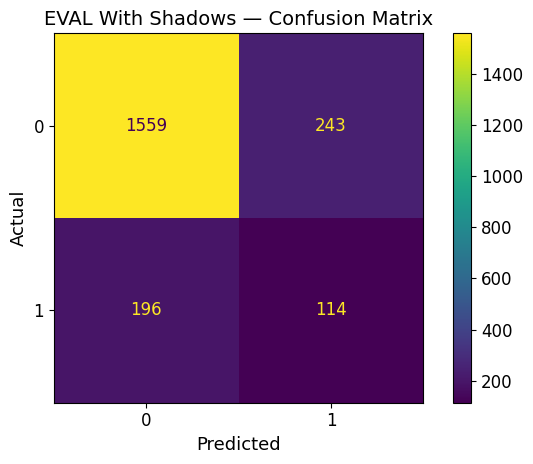

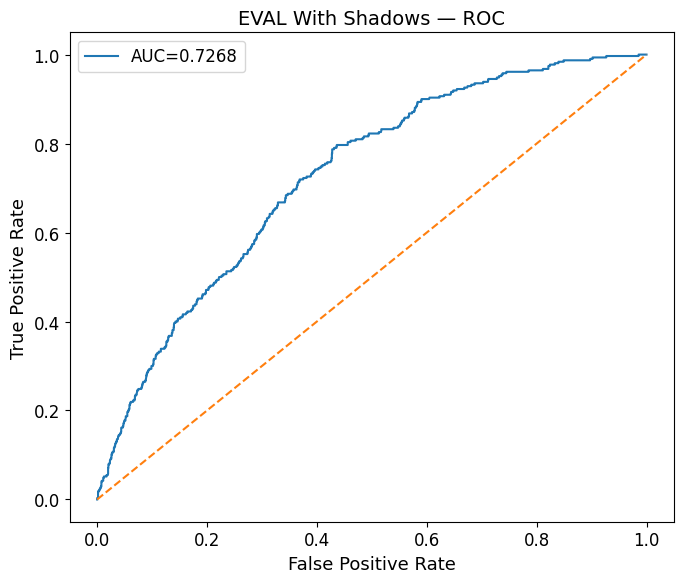

{'auc': 0.7267784898499874,
 'f1': 0.34182908545727136,
 'acc': 0.7921401515151515,
 'csi': np.float64(0.20614828209764918)}

In [ ]:
# Choose model and hyperparameters
model = "DNN"

n_epochs = 45
lr = .01

# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = num_features_ws)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader_ws, val_loader = val_loader_ws, classifier = classifier, device = device)
eval_and_plot(model, test_loader_ws, classifier=classifier, title="EVAL With Shadows", class_names=None, fontsize=fontsize, device=device)


# Create Hybrid Model No Shadows

<class 'tornadoq.models.BinaryDNN'>
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torc

<Figure size 600x500 with 0 Axes>

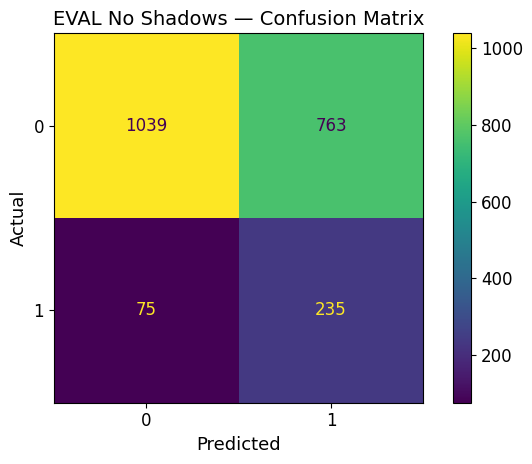

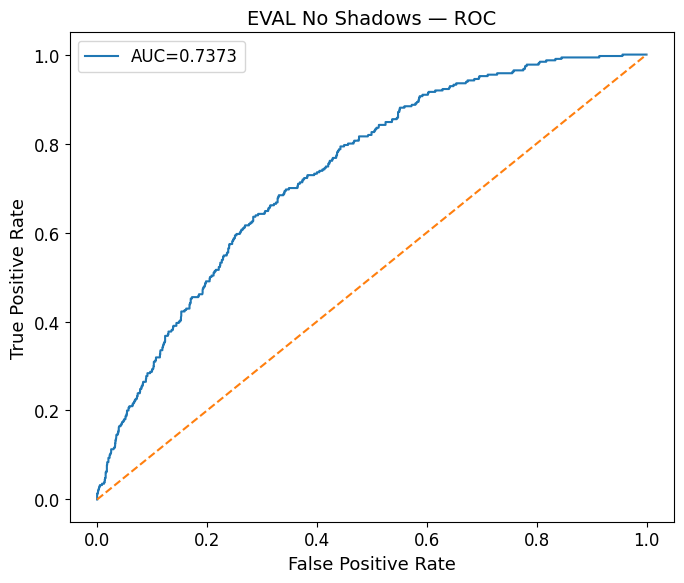

{'auc': 0.737265941069063,
 'f1': 0.35932721712538224,
 'acc': 0.603219696969697,
 'csi': np.float64(0.2190121155638397)}

In [ ]:
# Choose model and hyperparameters
model = "DNN"

n_epochs = 45
lr = .01

# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = num_features_ns)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader_ns, val_loader = val_loader_ns, classifier = classifier, device = device)
eval_and_plot(model, test_loader_ns, classifier=classifier, title="EVAL No Shadows", class_names=None, fontsize=fontsize, device=device)


# Instantiate StronglyEntangling Ansatz

8
<class 'tornadoq.models.BinaryPQC'>
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
to

<Figure size 600x500 with 0 Axes>

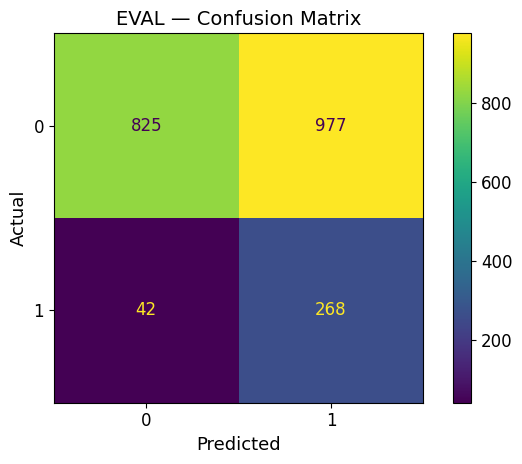

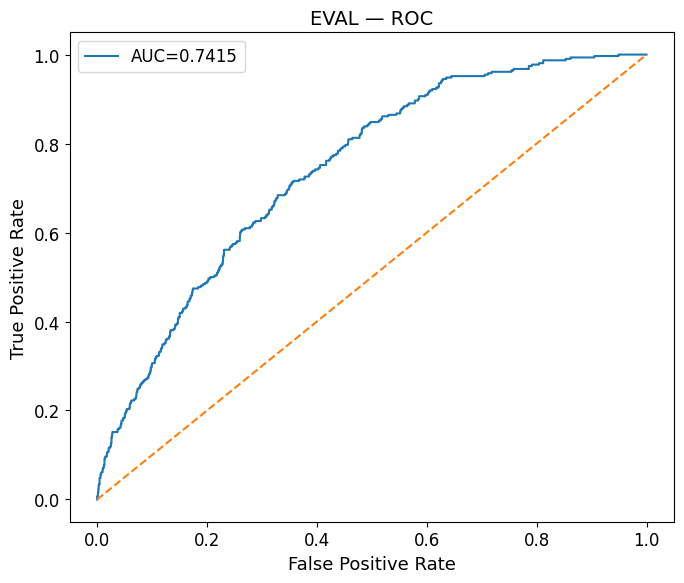

{'auc': 0.7415416562242669,
 'f1': 0.3446945337620579,
 'acc': 0.5175189393939394,
 'csi': np.float64(0.20823620823620823)}

In [8]:
# StronglyEntangling and RandomLayers need me to load the original dataset 

# Choose model and hyperparameters
# model = "DNN"
model = "StronglyEntangling"
# model = "RandomLayer"
n_epochs = 45
lr = .01
print(num_features_ns)

# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = num_features_ns, device = device)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader_ns, val_loader = val_loader_ns, classifier = classifier, device = device)
eval_and_plot(model, test_loader_ns, classifier=classifier, title="EVAL", class_names=None, fontsize=fontsize, device=device)

## Instantiate RandomLayers ansatz

<class 'tornadoq.models.BinaryPQC'>
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torc

<Figure size 600x500 with 0 Axes>

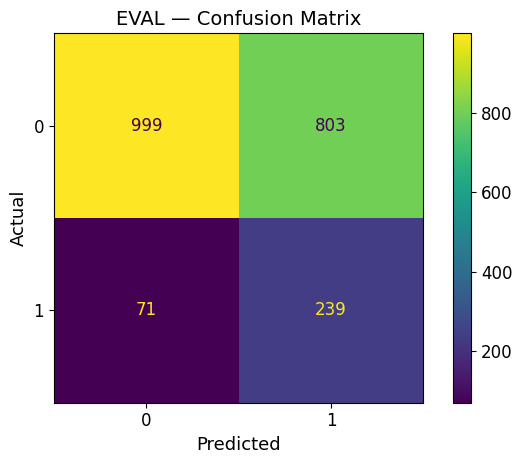

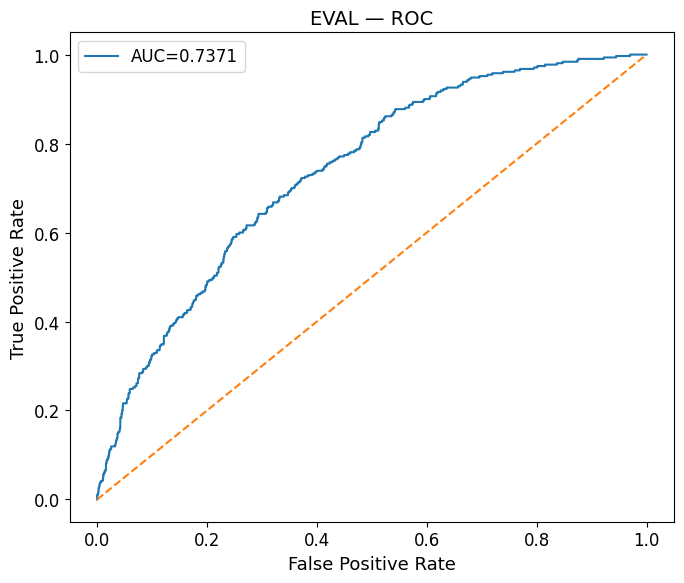

{'auc': 0.7371272063298843,
 'f1': 0.35355029585798814,
 'acc': 0.5861742424242424,
 'csi': np.float64(0.21473495058400718)}

In [9]:
# Choose model and hyperparameters
# model = "DNN"
# model = "StronglyEntangling"
model = "RandomLayer"
n_epochs = 45
lr = .01

# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = num_features_ns, device = device)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader_ns, val_loader = val_loader_ns, classifier = classifier, device = device)
eval_and_plot(model, test_loader_ns, classifier=classifier, title="EVAL", class_names=None, fontsize=fontsize, device=device)

2
